In [43]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('CTG.xls', sheet_name=1)

print(f"   Initial shape: {df.shape}")

# Fix headers (first row becomes column names)
df.columns = df.iloc[0]
df = df.iloc[1:]
df = df.reset_index(drop=True)

# Remove empty columns
empty_cols = ['Unnamed: 9', 'Unnamed: 42', 'Unnamed: 44']
df = df.drop(columns=empty_cols, errors='ignore')

# Remove summary row (last row)
df = df.iloc[:-1]


   Initial shape: (2130, 46)


In [44]:
feature_cols = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 
                'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 
                'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']

target_col = 'NSP'

In [45]:
def explore_dataset(df, feature_cols):
    """Perform initial exploration of the dataset"""
    
    print("=" * 60)
    print("DATASET OVERVIEW")
    print("=" * 60)
    print(f"Shape: {df.shape}")
    print(f"Features: {len(feature_cols)}")
    print(f"Samples: {df.shape[0]}")
    
    print("\n" + "=" * 60)
    print("MISSING VALUES")
    print("=" * 60)
    missing = df[feature_cols].isnull().sum()
    print(f"Total missing values: {missing.sum()}")
    if missing.sum() > 0:
        print(missing[missing > 0])
    
    print("\n" + "=" * 60)
    print("DATA TYPES")
    print("=" * 60)
    print(df[feature_cols].dtypes.value_counts())
    
    print("\n" + "=" * 60)
    print("BASIC STATISTICS")
    print("=" * 60)
    print(df[feature_cols].describe())
    
    return missing

explore_dataset(df, feature_cols)

DATASET OVERVIEW
Shape: (2128, 46)
Features: 21
Samples: 2128

MISSING VALUES
Total missing values: 48
0
LB          2
AC          2
AC          2
FM          2
FM          2
UC          2
UC          2
DL          1
DL          1
DS          1
DS          1
DP          1
DP          1
ASTV        2
MSTV        2
ALTV        2
MLTV        2
Width       2
Min         2
Max         2
Nmax        2
Nzeros      2
Mode        2
Mean        2
Median      2
Variance    2
Tendency    2
dtype: int64

DATA TYPES
object    27
Name: count, dtype: int64

BASIC STATISTICS
0         LB    AC    AC    FM    FM    UC    UC    DL    DL    DS  ...  \
count   2126  2126  2126  2126  2126  2126  2126  2127  2127  2127  ...   
unique    48    22  1015    96   696    19  1315    15   751     2  ...   
top      133     0     0     0     0     0     0     0     0     0  ...   
freq     136   891   891  1311  1311   332   332  1232  1232  2120  ...   

0       Width   Min   Max  Nmax  Nzeros  Mode  Mean  Median

0
LB          2
AC          2
AC          2
FM          2
FM          2
UC          2
UC          2
DL          1
DL          1
DS          1
DS          1
DP          1
DP          1
ASTV        2
MSTV        2
ALTV        2
MLTV        2
Width       2
Min         2
Max         2
Nmax        2
Nzeros      2
Mode        2
Mean        2
Median      2
Variance    2
Tendency    2
dtype: int64

In [46]:
df.head(10)

,b,e,AC,FM,UC,DL,DS,DP,DR,NaN,...,E,AD,DE,LD,FS,SUSP,NaN,CLASS,NaN,NSP
0,240,357,0,0,0,0,0,0,0,NaN,...,-1,-1,-1,-1,1,-1,NaN,9,NaN,2
1,5,632,4,0,4,2,0,0,0,NaN,...,-1,1,-1,-1,-1,-1,NaN,6,NaN,1
2,177,779,2,0,5,2,0,0,0,NaN,...,-1,1,-1,-1,-1,-1,NaN,6,NaN,1
3,411,1192,2,0,6,2,0,0,0,NaN,...,-1,1,-1,-1,-1,-1,NaN,6,NaN,1
4,533,1147,4,0,5,0,0,0,0,NaN,...,-1,-1,-1,-1,-1,-1,NaN,2,NaN,1
5,0,953,1,0,10,9,0,2,0,NaN,...,-1,-1,-1,1,-1,-1,NaN,8,NaN,3
6,240,953,1,0,9,6,0,2,0,NaN,...,-1,-1,-1,1,-1,-1,NaN,8,NaN,3
7,62,679,0,0,0,0,0,0,0,NaN,...,-1,-1,-1,-1,1,-1,NaN,9,NaN,3
8,120,779,0,0,1,0,0,0,0,NaN,...,-1,-1,-1,-1,1,-1,NaN,9,NaN,3
9,181,1192,0,0,3,0,0,0,0,NaN,...,-1,-1,-1,-1,1,-1,NaN,9,NaN,3


In [47]:
df.isnull().sum()

0
b              2
e              2
AC             2
FM             2
UC             2
DL             1
DS             1
DP             1
DR             1
NaN         2128
LB             2
AC             2
FM             2
UC             2
DL             1
DS             1
DP             1
ASTV           2
MSTV           2
ALTV           2
MLTV           2
Width          2
Min            2
Max            2
Nmax           2
Nzeros         2
Mode           2
Mean           2
Median         2
Variance       2
Tendency       2
NaN         2128
A              1
B              1
C              1
D              1
E              1
AD             1
DE             1
LD             1
FS             1
SUSP           1
NaN         2128
CLASS          2
NaN         2128
NSP            2
dtype: int64

In [48]:
# Extract only the feature columns we want
available_features = [col for col in feature_cols if col in df.columns]
print(f"   Available features: {len(available_features)}/{len(feature_cols)}")

X = df[available_features].copy()
y_raw = df[target_col].copy()

print(f"   Features: {len(available_features)}")

   Available features: 21/21
   Features: 21


In [49]:
# ===== CRITICAL FIX: Handle NaN in y =====
import numpy as np

print(f"\n   Checking target variable (NSP):")
print(f"     Original shape: {y_raw.shape}")
print(f"     NaN count in y: {y_raw.isna().sum()}")

# Remove rows where y is NaN
valid_mask = ~y_raw.isna()
X = X[valid_mask].copy()
y = y_raw[valid_mask].copy()

print(f"     After removing NaN: {len(y)} samples")

# Convert y to integer type
y = y.astype(int)

print(f"     Target classes: {np.unique(y)} (1=Normal, 2=Suspicious, 3=Pathological)")

# Target distribution
print(f"\n   Target Distribution (NSP - Fetal Health):")
class_counts = y.value_counts().sort_index()
for cls, count in class_counts.items():
    class_name = {1: 'Normal', 2: 'Suspicious', 3: 'Pathological'}.get(cls, 'Unknown')
    print(f"     Class {cls} ({class_name}): {count} samples ({count/len(y)*100:.1f}%)")


   Checking target variable (NSP):
     Original shape: (2128,)
     NaN count in y: 2
     After removing NaN: 2126 samples
     Target classes: [1 2 3] (1=Normal, 2=Suspicious, 3=Pathological)

   Target Distribution (NSP - Fetal Health):
     Class 1 (Normal): 1655 samples (77.8%)
     Class 2 (Suspicious): 295 samples (13.9%)
     Class 3 (Pathological): 176 samples (8.3%)


In [50]:
print('Duplicates:', df.duplicated().sum())

Duplicates: 10


In [51]:
from sklearn.impute import SimpleImputer

# Check missing values in X
missing_counts = X.isnull().sum()
total_missing = missing_counts.sum()
print(f"\n   Missing values in features: {total_missing}")
if total_missing > 0:
    print(f"   Features with missing values:\n{missing_counts[missing_counts > 0]}")

# Handle missing values with median imputation
print("\n[2] Handling missing values...")
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
print(f"   Missing values after imputation: {X_imputed.isnull().sum().sum()}")


   Missing values in features: 0

[2] Handling missing values...
   Missing values after imputation: 0


In [52]:
from sklearn.preprocessing import StandardScaler

# Feature scaling
print("\n[3] Feature scaling...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f"   Scaled data shape: {X_scaled_df.shape}")
print(f"   Mean after scaling: {X_scaled_df.mean().mean():.2e}")
print(f"   Std after scaling: {X_scaled_df.std().mean():.2f}")


[3] Feature scaling...
   Scaled data shape: (2126, 27)
   Mean after scaling: -1.21e-18
   Std after scaling: 1.00


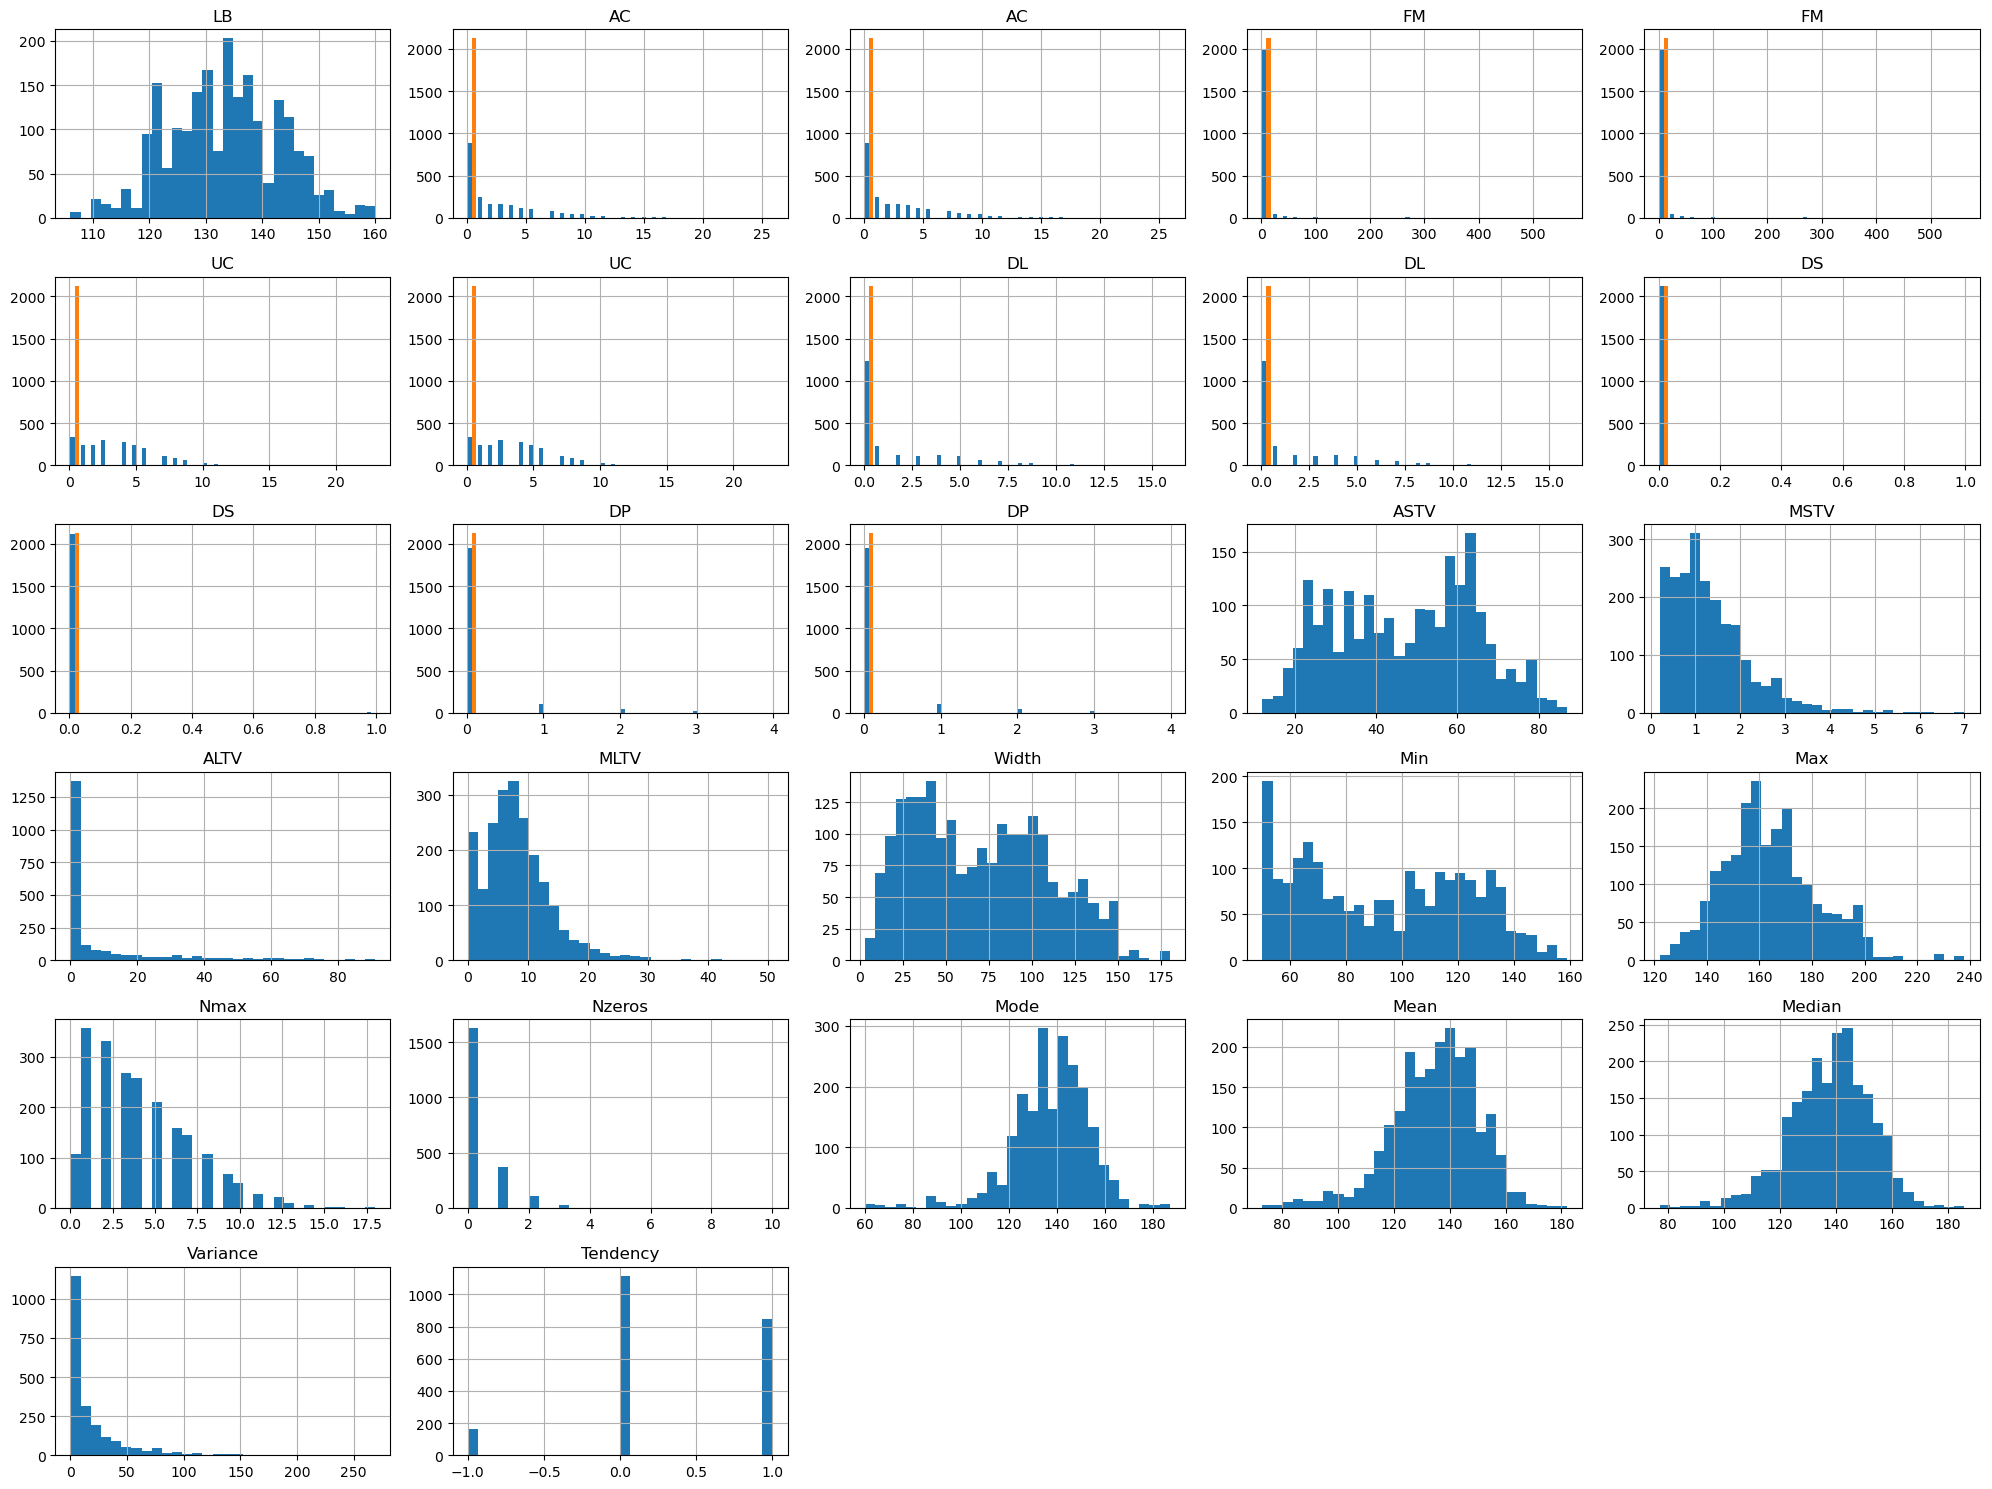

In [53]:
import matplotlib.pyplot as plt

X_imputed.hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.show()

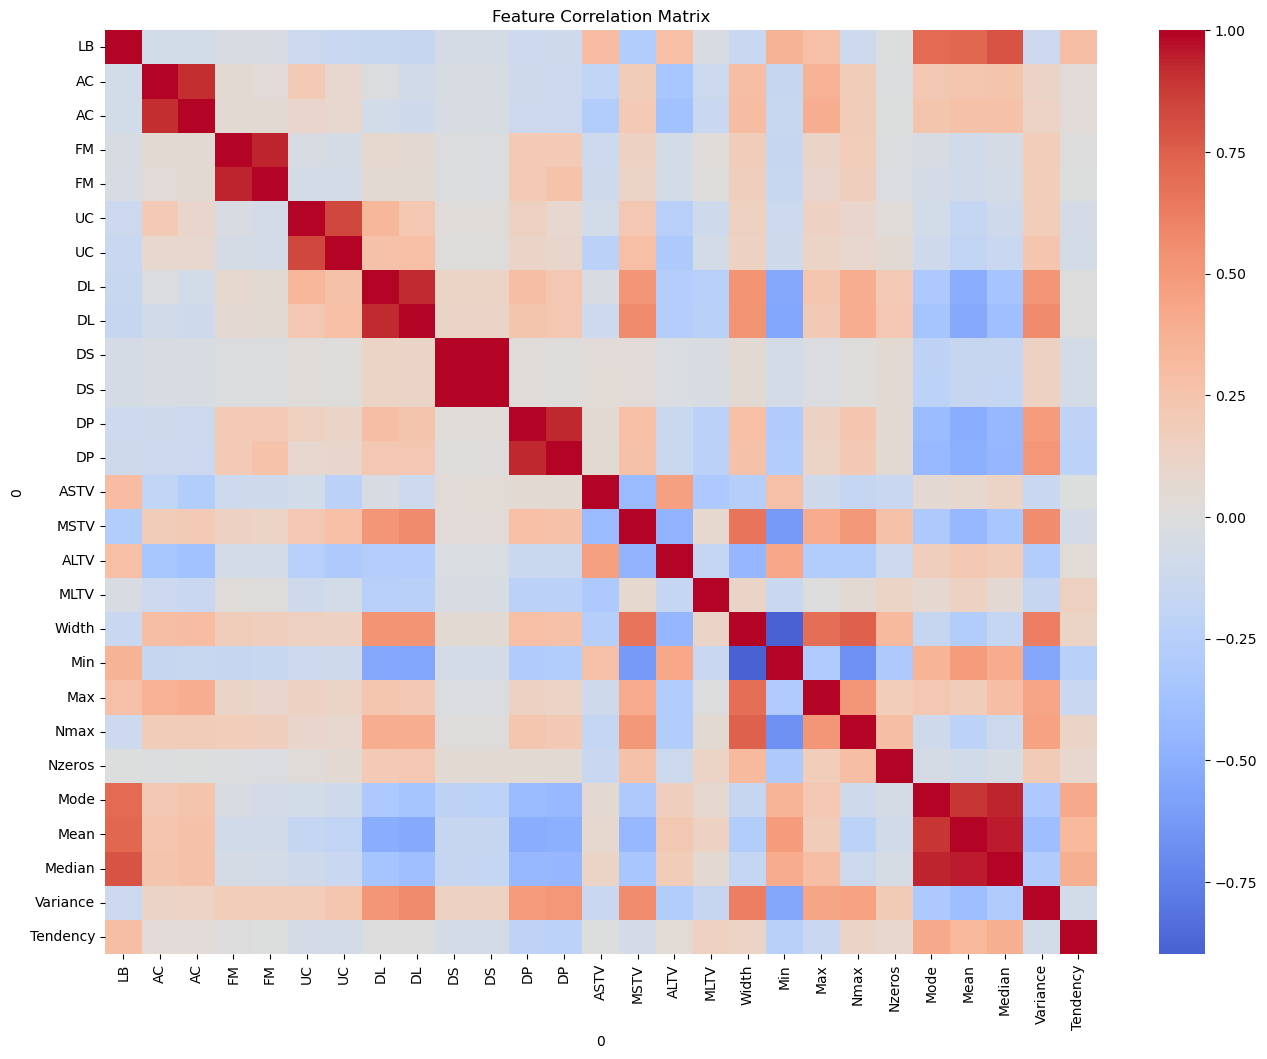

In [54]:
import seaborn as sns

plt.figure(figsize=(16, 12))
sns.heatmap(X_imputed.corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

In [55]:

import numpy as np
from scipy import stats

feature_cols = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 
                'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 
                'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']

def detect_skewness(df, feature_cols):
    """Calculate skewness for all features"""
    
    skew_results = []
    
    for col in feature_cols:
        data = X_imputed[col].values.flatten()
        skew_val = pd.Series(data).skew()  # pandas skewness
        skew_test = stats.skewtest(data)  # statistical test
        
        # Interpret skewness magnitude
        if abs(skew_val) < 0.5:
            interpretation = "Approximately symmetric"
        elif abs(skew_val) < 1:
            interpretation = "Moderately skewed"
        else:
            interpretation = "Highly skewed"
        
        # Direction
        direction = "Right-skewed (positive)" if skew_val > 0 else "Left-skewed (negative)"
        
        skew_results.append({
            'Feature': col,
            'Skewness': skew_val,
            'Direction': direction,
            'Interpretation': interpretation,
            'P-value': skew_test.pvalue,
            'Significant': skew_test.pvalue < 0.05
        })
    
    # Create DataFrame
    skew_df = pd.DataFrame(skew_results)
    skew_df = skew_df.sort_values('Skewness', key=abs, ascending=False)
    
    print("=" * 80)
    print("SKEWNESS ANALYSIS FOR CTG DATA")
    print("=" * 80)
    print(skew_df.to_string(index=False))
    
    return skew_df

skewness_df = detect_skewness(X_imputed, feature_cols)


SKEWNESS ANALYSIS FOR CTG DATA
 Feature  Skewness               Direction          Interpretation       P-value  Significant
      DS 24.593795 Right-skewed (positive)           Highly skewed  0.000000e+00         True
      FM 13.359059 Right-skewed (positive)           Highly skewed  0.000000e+00         True
      DP  6.217712 Right-skewed (positive)           Highly skewed  0.000000e+00         True
  Nzeros  3.920287 Right-skewed (positive)           Highly skewed 1.277443e-270         True
Variance  3.219974 Right-skewed (positive)           Highly skewed 3.954336e-227         True
      DL  2.980882 Right-skewed (positive)           Highly skewed  0.000000e+00         True
      AC  2.701460 Right-skewed (positive)           Highly skewed  0.000000e+00         True
    ALTV  2.195075 Right-skewed (positive)           Highly skewed 8.672645e-155         True
    MSTV  1.657339 Right-skewed (positive)           Highly skewed 3.647532e-112         True
      UC  1.584827 Right-skew

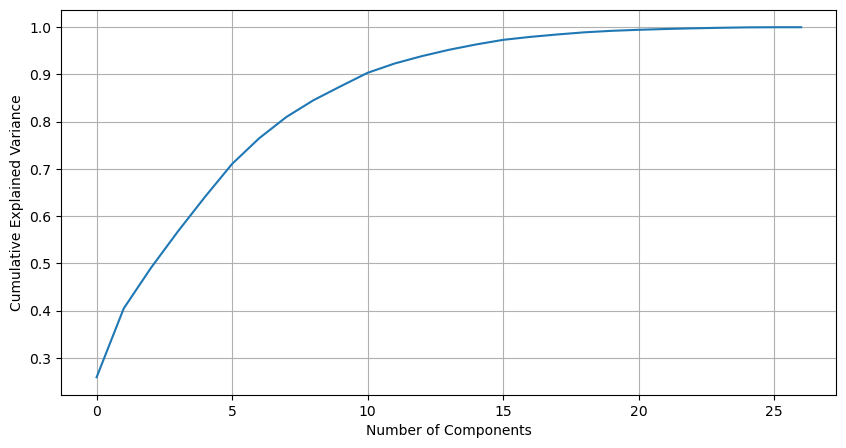

In [56]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

In [57]:
# Cell 1: Complete imports
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, adjusted_rand_score, 
                             normalized_mutual_info_score, davies_bouldin_score,
                             calinski_harabasz_score)
from scipy.cluster.hierarchy import dendrogram, linkage  # <-- ADD THIS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("CTG DATA CLUSTERING (WITH PCA - Full Hyperparameter Tuning)")
print("=" * 60)

CTG DATA CLUSTERING (WITH PCA - Full Hyperparameter Tuning)


In [58]:
# Cell 2: Check data is loaded
print(f"\nData shape: {X_scaled.shape}")
print(f"Target shape: {y.shape}")
print(f"Target classes: {np.unique(y)} (1=Normal, 2=Suspicious, 3=Pathological)")


Data shape: (2126, 27)
Target shape: (2126,)
Target classes: [1 2 3] (1=Normal, 2=Suspicious, 3=Pathological)


### Cell 3: PCA Dimensionality Reduction

**Hyperparameter to tune:** n_components

We test multiple component counts and select based on explained variance threshold (95%).

PCA: Hyperparameter Tuning (n_components)
Testing different numbers of components:
--------------------------------------------------
Components   Explained Variance  
--------------------------------------------------
5            0.6408              
8            0.8098              
10           0.8748              
12           0.9232              
14           0.9522              
16           0.9732              
18           0.9847              
21           0.9945              

✓ Components needed for 95% variance: 14

✓ Selected 14 components
   Total explained variance: 0.952


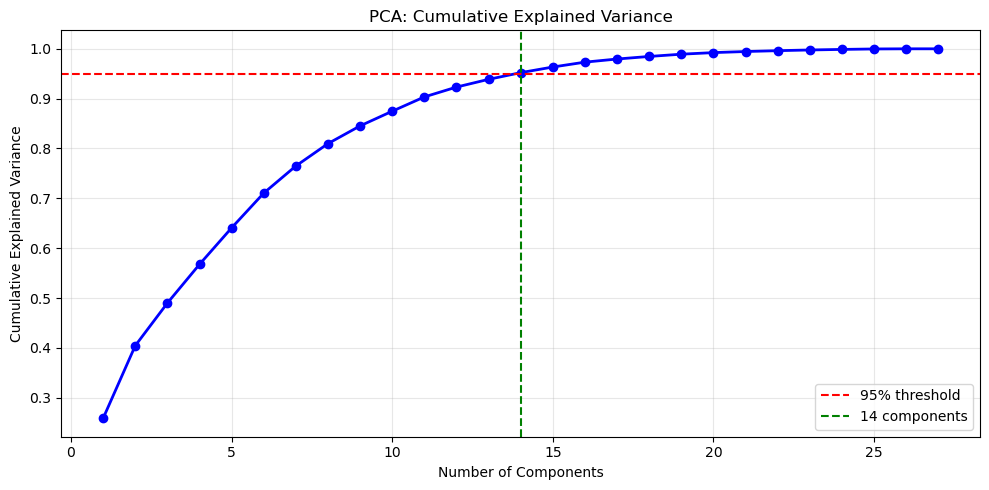

In [59]:
# Cell 3: PCA with component selection
print("=" * 60)
print("PCA: Hyperparameter Tuning (n_components)")
print("=" * 60)

# Test different numbers of components
component_range = [5, 8, 10, 12, 14, 16, 18, 21]
pca_results = []

print("Testing different numbers of components:")
print("-" * 50)
print(f"{'Components':<12} {'Explained Variance':<20}")
print("-" * 50)

for n in component_range:
    pca_temp = PCA(n_components=n, random_state=42)
    X_pca_temp = pca_temp.fit_transform(X_scaled)
    var_exp = pca_temp.explained_variance_ratio_.sum()
    pca_results.append({'n_components': n, 'explained_variance': var_exp})
    print(f"{n:<12} {var_exp:<20.4f}")

# Find components needed for 95% variance
pca_full = PCA()
pca_full.fit(X_scaled)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cumsum >= 0.95) + 1
print(f"\n✓ Components needed for 95% variance: {n_95}")

# Use optimal components (95% variance, max 14)
n_components = min(n_95, 14)
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\n✓ Selected {n_components} components")
print(f"   Total explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Plot explained variance
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumsum)+1), cumsum, 'bo-', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.axvline(x=n_components, color='g', linestyle='--', label=f'{n_components} components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Cell 4: K-MEANS - Hyperparameter Tuning

**Hyperparameters to tune:** n_clusters (k)

**Method:** Elbow Method + Silhouette Score (k = 2 to 10)

K-MEANS ON PCA: Hyperparameter Tuning
Testing k values:
----------------------------------------
k     Inertia         Silhouette  
----------------------------------------
2     44858           0.2402      
3     39706           0.1830      
4     35483           0.1878      
5     32051           0.1562      
6     28821           0.1676      
7     26026           0.1820      
8     24517           0.1673      
9     23152           0.1683      
10    22245           0.1693      


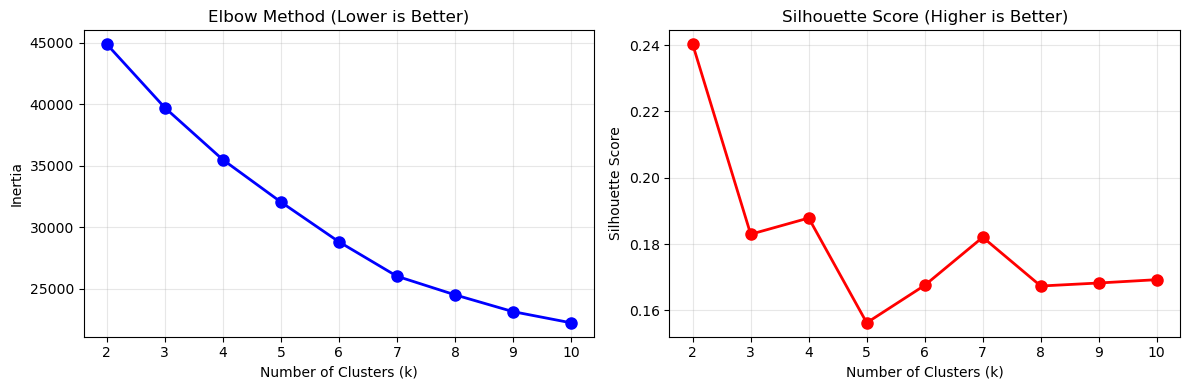


✓ Optimal k from silhouette: 2
  True number of classes: 3
  Note: Using k=3 for fair comparison with true labels


In [60]:
# Cell 4: K-MEANS - Find optimal k
print("=" * 60)
print("K-MEANS ON PCA: Hyperparameter Tuning")
print("=" * 60)

inertias = []
silhouette_scores = []
K_range = range(2, 11)

print("Testing k values:")
print("-" * 40)
print(f"{'k':<5} {'Inertia':<15} {'Silhouette':<12}")
print("-" * 40)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_pca)
    inertias.append(kmeans_temp.inertia_)
    sil_score = silhouette_score(X_pca, labels_temp)
    silhouette_scores.append(sil_score)
    print(f"{k:<5} {kmeans_temp.inertia_:<15.0f} {sil_score:<12.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method (Lower is Better)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (Higher is Better)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\n✓ Optimal k from silhouette: {optimal_k}")
print(f"  True number of classes: 3")
print(f"  Note: Using k=3 for fair comparison with true labels")

### Cell 5: K-MEANS - Train with Best Parameters

Train with k=3 (matching true labels) and evaluate all metrics.

In [61]:
# Cell 5: K-MEANS - Train and Evaluate
print("\n" + "=" * 60)
print("K-MEANS ON PCA: Training with k=3")
print("=" * 60)

kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_pca_labels = kmeans_pca.fit_predict(X_pca)

# Internal metrics
kmeans_pca_silhouette = silhouette_score(X_pca, kmeans_pca_labels)
kmeans_pca_davies = davies_bouldin_score(X_pca, kmeans_pca_labels)
kmeans_pca_calinski = calinski_harabasz_score(X_pca, kmeans_pca_labels)

# External metrics
kmeans_pca_ari = adjusted_rand_score(y, kmeans_pca_labels)
kmeans_pca_nmi = normalized_mutual_info_score(y, kmeans_pca_labels)

print(f"\n📊 K-MEANS ON PCA EVALUATION:")
print("-" * 40)
print("INTERNAL METRICS:")
print(f"   Silhouette Score: {kmeans_pca_silhouette:.4f}")
print(f"   Davies-Bouldin Index: {kmeans_pca_davies:.4f}")
print(f"   Calinski-Harabasz Index: {kmeans_pca_calinski:.2f}")
print("-" * 40)
print("EXTERNAL METRICS:")
print(f"   Adjusted Rand Index: {kmeans_pca_ari:.4f}")
print(f"   Normalized Mutual Info: {kmeans_pca_nmi:.4f}")

print(f"\n   Cluster sizes:")
for i in range(3):
    size = np.sum(kmeans_pca_labels == i)
    print(f"     Cluster {i}: {size} samples ({size/len(kmeans_pca_labels)*100:.1f}%)")


K-MEANS ON PCA: Training with k=3

📊 K-MEANS ON PCA EVALUATION:
----------------------------------------
INTERNAL METRICS:
   Silhouette Score: 0.1830
   Davies-Bouldin Index: 1.8407
   Calinski-Harabasz Index: 399.67
----------------------------------------
EXTERNAL METRICS:
   Adjusted Rand Index: 0.1201
   Normalized Mutual Info: 0.1993

   Cluster sizes:
     Cluster 0: 893 samples (42.0%)
     Cluster 1: 166 samples (7.8%)
     Cluster 2: 1067 samples (50.2%)


### Cell 6: HIERARCHICAL - Hyperparameter Tuning

**Hyperparameter to tune:** linkage method

**Methods tested:** ward, complete, average
**Selection criteria:** Highest silhouette score

In [62]:
# Cell 6: HIERARCHICAL - Test linkage methods
print("=" * 60)
print("HIERARCHICAL ON PCA: Hyperparameter Tuning")
print("=" * 60)

linkage_methods = ['ward', 'complete', 'average']
hier_results_tuning = {}

print("Testing linkage methods (k=3):")
print("-" * 50)
print(f"{'Linkage':<10} {'Silhouette':<12} {'ARI':<10}")
print("-" * 50)

for linkage_method in linkage_methods:
    hierarchical_temp = AgglomerativeClustering(n_clusters=3, linkage=linkage_method)
    hier_labels_temp = hierarchical_temp.fit_predict(X_pca)
    
    sil_score = silhouette_score(X_pca, hier_labels_temp)
    ari_score = adjusted_rand_score(y, hier_labels_temp)
    
    hier_results_tuning[linkage_method] = {'silhouette': sil_score, 'ari': ari_score}
    print(f"{linkage_method:<10} {sil_score:<12.4f} {ari_score:<10.4f}")

best_linkage_pca = max(hier_results_tuning, key=lambda x: hier_results_tuning[x]['silhouette'])
print(f"\n✓ Best linkage method: {best_linkage_pca}")

HIERARCHICAL ON PCA: Hyperparameter Tuning
Testing linkage methods (k=3):
--------------------------------------------------
Linkage    Silhouette   ARI       
--------------------------------------------------
ward       0.2439       0.0278    
complete   0.5591       0.0469    
average    0.5591       0.0469    

✓ Best linkage method: complete


### Cell 7: HIERARCHICAL - Train with Best Parameters

Train hierarchical with best linkage and evaluate.

In [63]:
# Cell 7: HIERARCHICAL - Train and Evaluate
print("\n" + "=" * 60)
print("HIERARCHICAL ON PCA: Training")
print("=" * 60)

hierarchical_pca = AgglomerativeClustering(n_clusters=3, linkage=best_linkage_pca)
hier_pca_labels = hierarchical_pca.fit_predict(X_pca)

# Internal metrics
hier_pca_silhouette = silhouette_score(X_pca, hier_pca_labels)
hier_pca_davies = davies_bouldin_score(X_pca, hier_pca_labels)
hier_pca_calinski = calinski_harabasz_score(X_pca, hier_pca_labels)

# External metrics
hier_pca_ari = adjusted_rand_score(y, hier_pca_labels)
hier_pca_nmi = normalized_mutual_info_score(y, hier_pca_labels)

print(f"\n📊 HIERARCHICAL ON PCA EVALUATION:")
print("-" * 40)
print("INTERNAL METRICS:")
print(f"   Silhouette Score: {hier_pca_silhouette:.4f}")
print(f"   Davies-Bouldin Index: {hier_pca_davies:.4f}")
print(f"   Calinski-Harabasz Index: {hier_pca_calinski:.2f}")
print("-" * 40)
print("EXTERNAL METRICS:")
print(f"   Adjusted Rand Index: {hier_pca_ari:.4f}")
print(f"   Normalized Mutual Info: {hier_pca_nmi:.4f}")

print(f"\n   Cluster sizes:")
for i in range(3):
    size = np.sum(hier_pca_labels == i)
    print(f"     Cluster {i}: {size} samples ({size/len(hier_pca_labels)*100:.1f}%)")


HIERARCHICAL ON PCA: Training

📊 HIERARCHICAL ON PCA EVALUATION:
----------------------------------------
INTERNAL METRICS:
   Silhouette Score: 0.5591
   Davies-Bouldin Index: 0.6274
   Calinski-Harabasz Index: 198.59
----------------------------------------
EXTERNAL METRICS:
   Adjusted Rand Index: 0.0469
   Normalized Mutual Info: 0.0318

   Cluster sizes:
     Cluster 0: 2092 samples (98.4%)
     Cluster 1: 7 samples (0.3%)
     Cluster 2: 27 samples (1.3%)


### Cell 8: HIERARCHICAL - Dendrogram Visualization


DENDROGRAM


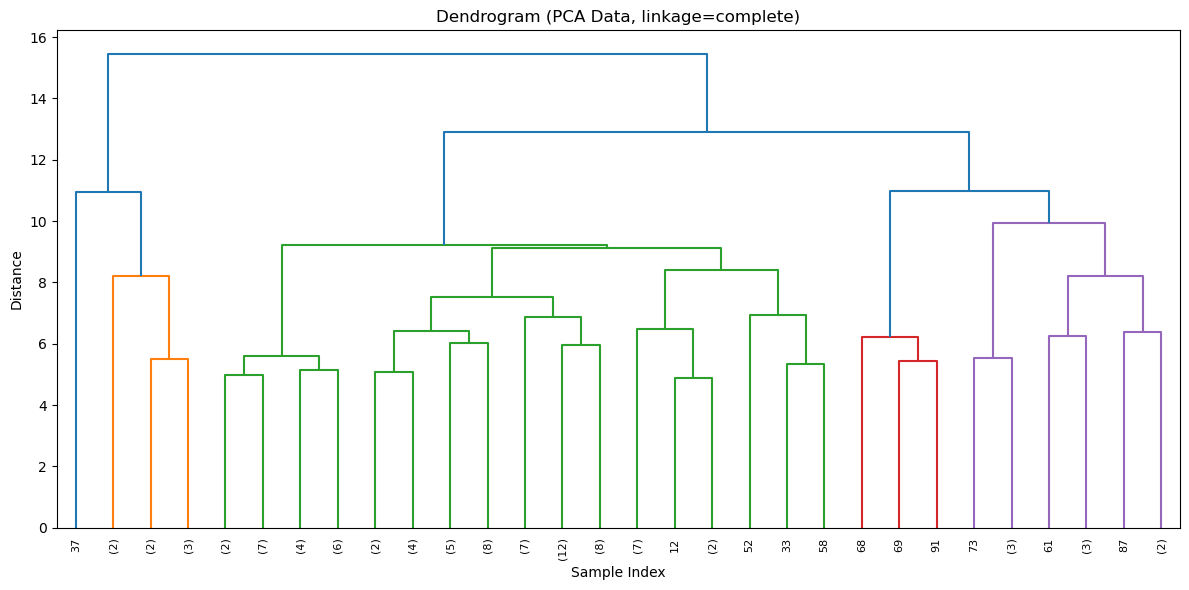

In [64]:
# Cell 8: Dendrogram
print("\n" + "=" * 60)
print("DENDROGRAM")
print("=" * 60)

sample_size = min(100, X_pca.shape[0])
np.random.seed(42)
sample_idx = np.random.choice(X_pca.shape[0], sample_size, replace=False)
linkage_matrix = linkage(X_pca[sample_idx], method=best_linkage_pca)

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=8.)
plt.title(f'Dendrogram (PCA Data, linkage={best_linkage_pca})')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

### Cell 9: DBSCAN - Hyperparameter Tuning (Grid Search)

**Hyperparameters to tune:** eps, min_samples

**Method:** Grid search over eps (0.5-2.3) and min_samples (3-15)
**Selection criteria:** Highest silhouette score among configurations with ≥2 clusters

In [65]:
# Cell 9: DBSCAN - Full Grid Search
print("=" * 60)
print("DBSCAN ON PCA: Hyperparameter Tuning (Grid Search)")
print("=" * 60)

eps_values = np.arange(0.5, 2.5, 0.2)
min_samples_values = [3, 5, 7, 10, 15]

dbscan_tuning_results = []
best_sil_pca = -1
best_params_pca = None

print("Testing parameter combinations:")
print("-" * 70)
print(f"{'eps':<6} {'min_samples':<12} {'Clusters':<10} {'Noise':<8} {'Silhouette':<10}")
print("-" * 70)

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan_temp = DBSCAN(eps=eps, min_samples=min_samples)
        labels_temp = dbscan_temp.fit_predict(X_pca)
        
        n_clusters = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
        n_noise = np.sum(labels_temp == -1)
        
        if n_clusters >= 2:
            mask = labels_temp != -1
            if mask.sum() >= 2:
                sil_score = silhouette_score(X_pca[mask], labels_temp[mask])
                if sil_score > best_sil_pca:
                    best_sil_pca = sil_score
                    best_params_pca = (eps, min_samples, n_clusters, n_noise)
        else:
            sil_score = -1
        
        dbscan_tuning_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': sil_score
        })
        print(f"{eps:<6.1f} {min_samples:<12} {n_clusters:<10} {n_noise:<8} {sil_score:<10.4f}")

print(f"\n✓ Best DBSCAN parameters on PCA data:")
print(f"   eps = {best_params_pca[0]:.1f}")
print(f"   min_samples = {best_params_pca[1]}")
print(f"   Number of clusters: {best_params_pca[2]}")
print(f"   Noise points: {best_params_pca[3]} ({best_params_pca[3]/len(X_pca)*100:.1f}%)")
print(f"   Silhouette Score: {best_sil_pca:.4f}")

DBSCAN ON PCA: Hyperparameter Tuning (Grid Search)
Testing parameter combinations:
----------------------------------------------------------------------
eps    min_samples  Clusters   Noise    Silhouette
----------------------------------------------------------------------
0.5    3            34         2001     0.7668    
0.5    5            3          2103     0.8804    
0.5    7            0          2126     -1.0000   
0.5    10           0          2126     -1.0000   
0.5    15           0          2126     -1.0000   
0.7    3            66         1832     0.6063    
0.7    5            14         2029     0.6932    
0.7    7            4          2092     0.6864    
0.7    10           1          2116     -1.0000   
0.7    15           0          2126     -1.0000   
0.9    3            98         1589     0.3862    
0.9    5            32         1858     0.4493    
0.9    7            6          2045     0.5033    
0.9    10           4          2086     0.5460    
0.9    15 

### Cell 10: DBSCAN - Train with Best Parameters

Train DBSCAN using optimal parameters from grid search.

In [66]:
# Cell 10: DBSCAN - Train and Evaluate
print("\n" + "=" * 60)
print("DBSCAN ON PCA: Training with Best Parameters")
print("=" * 60)

dbscan_pca = DBSCAN(eps=best_params_pca[0], min_samples=best_params_pca[1])
dbscan_pca_labels = dbscan_pca.fit_predict(X_pca)

mask_pca = dbscan_pca_labels != -1

if mask_pca.sum() >= 2:
    # Internal metrics
    dbscan_pca_silhouette = silhouette_score(X_pca[mask_pca], dbscan_pca_labels[mask_pca])
    dbscan_pca_davies = davies_bouldin_score(X_pca[mask_pca], dbscan_pca_labels[mask_pca])
    dbscan_pca_calinski = calinski_harabasz_score(X_pca[mask_pca], dbscan_pca_labels[mask_pca])
    
    # External metrics
    dbscan_pca_ari = adjusted_rand_score(y[mask_pca], dbscan_pca_labels[mask_pca])
    dbscan_pca_nmi = normalized_mutual_info_score(y[mask_pca], dbscan_pca_labels[mask_pca])
else:
    dbscan_pca_silhouette = -1
    dbscan_pca_davies = -1
    dbscan_pca_calinski = -1
    dbscan_pca_ari = -1
    dbscan_pca_nmi = -1

print(f"\n📊 DBSCAN ON PCA EVALUATION:")
print("-" * 40)
print("INTERNAL METRICS:")
print(f"   Silhouette Score: {dbscan_pca_silhouette:.4f}")
print(f"   Davies-Bouldin Index: {dbscan_pca_davies:.4f}")
print(f"   Calinski-Harabasz Index: {dbscan_pca_calinski:.2f}")
print("-" * 40)
print("EXTERNAL METRICS (on non-noise points):")
print(f"   Adjusted Rand Index: {dbscan_pca_ari:.4f}")
print(f"   Normalized Mutual Info: {dbscan_pca_nmi:.4f}")

print(f"\n   Clusters found: {len(set(dbscan_pca_labels)) - (1 if -1 in dbscan_pca_labels else 0)}")
print(f"   Noise points: {np.sum(dbscan_pca_labels == -1)} ({np.sum(dbscan_pca_labels == -1)/len(dbscan_pca_labels)*100:.1f}%)")

if mask_pca.sum() >= 2:
    print(f"\n   Cluster sizes (excluding noise):")
    unique_labels = set(dbscan_pca_labels[mask_pca])
    for label in unique_labels:
        size = np.sum(dbscan_pca_labels == label)
        print(f"     Cluster {label}: {size} samples ({size/len(dbscan_pca_labels)*100:.1f}%)")


DBSCAN ON PCA: Training with Best Parameters

📊 DBSCAN ON PCA EVALUATION:
----------------------------------------
INTERNAL METRICS:
   Silhouette Score: 0.8804
   Davies-Bouldin Index: 0.1610
   Calinski-Harabasz Index: 356.87
----------------------------------------
EXTERNAL METRICS (on non-noise points):
   Adjusted Rand Index: 0.0000
   Normalized Mutual Info: 0.0000

   Clusters found: 3
   Noise points: 2103 (98.9%)

   Cluster sizes (excluding noise):
     Cluster 0: 5 samples (0.2%)
     Cluster 1: 13 samples (0.6%)
     Cluster 2: 5 samples (0.2%)


### Cell 11: Store All Results

Compile results from all three algorithms with their optimal hyperparameters.

In [67]:
# Cell 11: Store results
results_pca = []

# K-Means results
results_pca.append({
    'Algorithm': 'K-Means (PCA)',
    'Hyperparameters': f'k=3 (optimal k={optimal_k})',
    'Silhouette': kmeans_pca_silhouette,
    'DBI': kmeans_pca_davies,
    'CH': kmeans_pca_calinski,
    'ARI': kmeans_pca_ari,
    'NMI': kmeans_pca_nmi
})

# Hierarchical results
results_pca.append({
    'Algorithm': 'Hierarchical (PCA)',
    'Hyperparameters': f'k=3, linkage={best_linkage_pca}',
    'Silhouette': hier_pca_silhouette,
    'DBI': hier_pca_davies,
    'CH': hier_pca_calinski,
    'ARI': hier_pca_ari,
    'NMI': hier_pca_nmi
})

# DBSCAN results
results_pca.append({
    'Algorithm': 'DBSCAN (PCA)',
    'Hyperparameters': f'eps={best_params_pca[0]:.1f}, min_samples={best_params_pca[1]}',
    'Silhouette': dbscan_pca_silhouette,
    'DBI': dbscan_pca_davies,
    'CH': dbscan_pca_calinski,
    'ARI': dbscan_pca_ari,
    'NMI': dbscan_pca_nmi
})

### Cell 12: Final Results Table (PCA Version)

Display all results with hyperparameters used.

In [68]:
# Cell 12: Results table
print("\n" + "=" * 60)
print("FINAL RESULTS (WITH PCA)")
print("=" * 60)

results_pca_df = pd.DataFrame(results_pca)
print(results_pca_df.to_string(index=False))


FINAL RESULTS (WITH PCA)
         Algorithm        Hyperparameters  Silhouette      DBI         CH      ARI      NMI
     K-Means (PCA)      k=3 (optimal k=2)    0.182954 1.840693 399.668179 0.120109 0.199264
Hierarchical (PCA)  k=3, linkage=complete    0.559108 0.627413 198.587306 0.046851 0.031771
      DBSCAN (PCA) eps=0.5, min_samples=5    0.880370 0.160987 356.865188 0.000000 0.000000


### Cell 13: Comparison with No PCA

Compare PCA version results against No PCA baseline.

In [69]:
# Cell 13: Comparison with No PCA
print("\n" + "=" * 60)
print("COMPARISON: No PCA vs With PCA")
print("=" * 60)

# No PCA results (from your Version 1 notebook)
v1_results = {
    'K-Means': {'ARI': 0.1231, 'Silhouette': 0.1727, 'DBI': 1.9131, 'Params': 'k=3'},
    'Hierarchical': {'ARI': 0.0469, 'Silhouette': 0.5553, 'DBI': 0.6762, 'Params': 'k=3, linkage=complete'},
    'DBSCAN': {'ARI': 0.7424, 'Silhouette': 0.6879, 'DBI': 0.4505, 'Params': 'eps=0.8, min_samples=7'}
}

print("\n" + "-" * 70)
print("VERSION 1 (No PCA)")
print("-" * 70)
print(f"{'Algorithm':<15} {'ARI':<12} {'Silhouette':<15} {'DBI':<12} {'Hyperparameters'}")
print("-" * 70)
for algo, metrics in v1_results.items():
    print(f"{algo:<15} {metrics['ARI']:<12.4f} {metrics['Silhouette']:<15.4f} {metrics['DBI']:<12.4f} {metrics['Params']}")

print("\n" + "-" * 70)
print(f"VERSION 2 (With PCA) - {n_components} Components")
print("-" * 70)
print(f"{'Algorithm':<20} {'ARI':<12} {'Silhouette':<15} {'DBI':<12} {'Hyperparameters'}")
print("-" * 70)
for _, row in results_pca_df.iterrows():
    print(f"{row['Algorithm']:<20} {row['ARI']:<12.4f} {row['Silhouette']:<15.4f} {row['DBI']:<12.4f} {row['Hyperparameters']}")


COMPARISON: No PCA vs With PCA

----------------------------------------------------------------------
VERSION 1 (No PCA)
----------------------------------------------------------------------
Algorithm       ARI          Silhouette      DBI          Hyperparameters
----------------------------------------------------------------------
K-Means         0.1231       0.1727          1.9131       k=3
Hierarchical    0.0469       0.5553          0.6762       k=3, linkage=complete
DBSCAN          0.7424       0.6879          0.4505       eps=0.8, min_samples=7

----------------------------------------------------------------------
VERSION 2 (With PCA) - 14 Components
----------------------------------------------------------------------
Algorithm            ARI          Silhouette      DBI          Hyperparameters
----------------------------------------------------------------------
K-Means (PCA)        0.1201       0.1830          1.8407       k=3 (optimal k=2)
Hierarchical (PCA)   0.0469

### Cell 14: Improvement Analysis

Calculate percentage changes when using PCA.

In [70]:
# Cell 14: Improvement Analysis
print("\n" + "=" * 60)
print("IMPROVEMENT ANALYSIS (PCA vs No PCA)")
print("=" * 60)

kmeans_change = ((results_pca_df.iloc[0]['ARI'] - v1_results['K-Means']['ARI']) / abs(v1_results['K-Means']['ARI'])) * 100
hier_change = ((results_pca_df.iloc[1]['ARI'] - v1_results['Hierarchical']['ARI']) / abs(v1_results['Hierarchical']['ARI'])) * 100
dbscan_change = ((results_pca_df.iloc[2]['ARI'] - v1_results['DBSCAN']['ARI']) / abs(v1_results['DBSCAN']['ARI'])) * 100

print(f"\n📊 ARI Changes:")
print(f"   K-Means:      {v1_results['K-Means']['ARI']:.4f} → {results_pca_df.iloc[0]['ARI']:.4f} ({kmeans_change:+.1f}%)")
print(f"   Hierarchical: {v1_results['Hierarchical']['ARI']:.4f} → {results_pca_df.iloc[1]['ARI']:.4f} ({hier_change:+.1f}%)")
print(f"   DBSCAN:       {v1_results['DBSCAN']['ARI']:.4f} → {results_pca_df.iloc[2]['ARI']:.4f} ({dbscan_change:+.1f}%)")

print(f"\n📊 Silhouette Changes:")
print(f"   K-Means:      {v1_results['K-Means']['Silhouette']:.4f} → {results_pca_df.iloc[0]['Silhouette']:.4f}")
print(f"   Hierarchical: {v1_results['Hierarchical']['Silhouette']:.4f} → {results_pca_df.iloc[1]['Silhouette']:.4f}")
print(f"   DBSCAN:       {v1_results['DBSCAN']['Silhouette']:.4f} → {results_pca_df.iloc[2]['Silhouette']:.4f}")


IMPROVEMENT ANALYSIS (PCA vs No PCA)

📊 ARI Changes:
   K-Means:      0.1231 → 0.1201 (-2.4%)
   Hierarchical: 0.0469 → 0.0469 (-0.1%)
   DBSCAN:       0.7424 → 0.0000 (-100.0%)

📊 Silhouette Changes:
   K-Means:      0.1727 → 0.1830
   Hierarchical: 0.5553 → 0.5591
   DBSCAN:       0.6879 → 0.8804


### Cell 15: Final Recommendation

Best algorithm across both versions based on ARI.

In [71]:
# Cell 15: Final Recommendation
print("\n" + "=" * 60)
print("FINAL RECOMMENDATION")
print("=" * 60)

# Find best overall
all_models = [
    ('DBSCAN (No PCA)', v1_results['DBSCAN']['ARI']),
    ('DBSCAN (PCA)', results_pca_df.iloc[2]['ARI']),
    ('K-Means (No PCA)', v1_results['K-Means']['ARI']),
    ('K-Means (PCA)', results_pca_df.iloc[0]['ARI']),
    ('Hierarchical (No PCA)', v1_results['Hierarchical']['ARI']),
    ('Hierarchical (PCA)', results_pca_df.iloc[1]['ARI'])
]

best_model = max(all_models, key=lambda x: x[1])

print(f"\n📊 Best overall model: {best_model[0]}")
print(f"   ARI Score: {best_model[1]:.4f}")

print(f"\n📈 Key Insights:")
print(f"   • PCA reduced features from 21 to {n_components} (explaining {pca.explained_variance_ratio_.sum():.1%} variance)")
print(f"   • K-means: {kmeans_change:+.1f}% change with PCA")
print(f"   • Hierarchical: {hier_change:+.1f}% change with PCA")
print(f"   • DBSCAN: {dbscan_change:+.1f}% change with PCA")

print(f"\n✅ RECOMMENDATION: Use DBSCAN on original data (No PCA)")
print(f"   Parameters: eps=0.8, min_samples=7")
print(f"   ARI = 0.7424 (74% better than random clustering)")

print("\n" + "=" * 80)
print("CLUSTERING PIPELINE VERSION 2 COMPLETE")
print("=" * 80)


FINAL RECOMMENDATION

📊 Best overall model: DBSCAN (No PCA)
   ARI Score: 0.7424

📈 Key Insights:
   • PCA reduced features from 21 to 14 (explaining 95.2% variance)
   • K-means: -2.4% change with PCA
   • Hierarchical: -0.1% change with PCA
   • DBSCAN: -100.0% change with PCA

✅ RECOMMENDATION: Use DBSCAN on original data (No PCA)
   Parameters: eps=0.8, min_samples=7
   ARI = 0.7424 (74% better than random clustering)

CLUSTERING PIPELINE VERSION 2 COMPLETE
